## NASA tracks

Here I will load and analyse the NASA tracks to find distributions of length, genisis and central pressure.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import importlib
import pandas as pd
import pystormtracker as pst
import stormtracker as st
importlib.reload(st)  # pick up edits in stormtracker.py without restarting the kernel
from pystormtracker.hodges.rsplice import filter_rsplice


In [2]:
# format (west, east, south, north) in degrees
REGION = (-80, 20, 30, 80)   # smaller region for tracking, limited by the domain, 10 deg smaller
DOMAIN = (-90, 30, 20, 90)   # tracking domain (region + buffer), limited by the downloaded data

In [3]:
st_tracks = st.load_st_report(file_path='/Users/asgerthormann/Documents/uni/master/master_code/master_thesis/PyStormTracker/Data/st_report.txt', variable='msl',units='Pa', scale=100.0)  # load storm report from Hodges et al. (2017)

In [4]:
tracks, summary, points = st.postprocess_tracks(st_tracks,
                                                    region=REGION,
                                                    domain=DOMAIN,
                                                    #time_range=TIME_RANGE,
                                                    region_criterion='passes',
                                                    min_points_in_region=2,
                                                    rsplice_min_points=8,                     # >= 48 h at 6 h
                                                    rsplice_max_points=None,
                                                    rsplice_distance_degrees=10.0,            # genesis -> lysis >= 10 degrees
                                                    rsplice_distance_mode='endpoint',
                                                    rsplice_cadence=np.timedelta64(6, 'h'),   # ERA5 time step
                                                    edge_buffer_deg=5,
                                                    max_frac_at_edge=0.25,
                                                    min_peak=None,
                                                    drop_time_truncated=False,)
st.filter_report(summary)

raw tracks: 1321, kept: 89


,removed_by_this_criterion,removed_only_by_this_criterion
rsplice,553,60
region,1119,2
edge,1168,52
peak,0,0
time,0,0


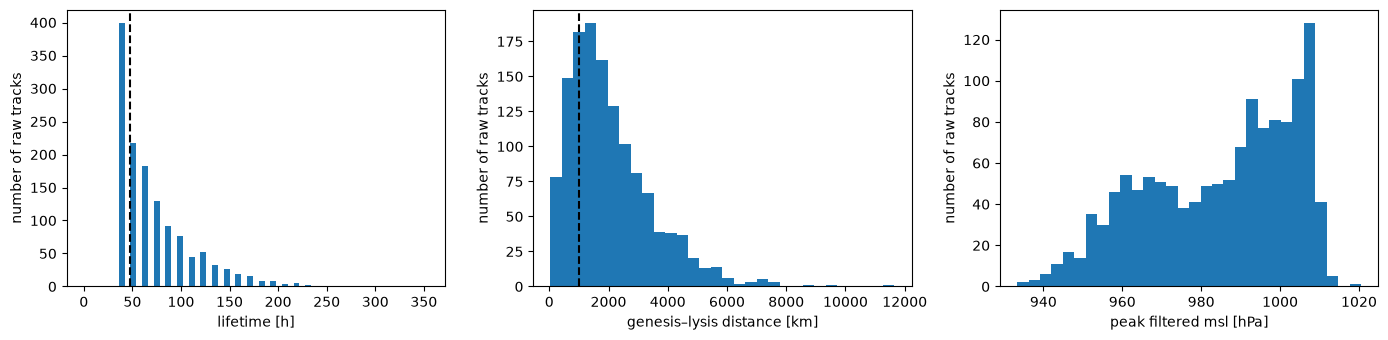

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(14, 3.5))
axs[0].hist(summary['duration_h'], bins=np.arange(0, summary['duration_h'].max() + 12, 6))
axs[0].axvline(48, color='k', ls='--'); axs[0].set_xlabel('lifetime [h]')
axs[1].hist(summary['separation_km'], bins=30)
axs[1].axvline(1000, color='k', ls='--'); axs[1].set_xlabel('genesis–lysis distance [km]')
axs[2].hist(summary['msl_peak']*1e-2, bins=30)
axs[2].set_xlabel('peak filtered msl [hPa]')
for ax in axs: ax.set_ylabel('number of raw tracks')
plt.tight_layout()

# Below i will fin the limits of the data set

In [6]:
min_lifetime = summary['duration_h'].min()
count_min_lifetime = (summary['duration_h'] == min_lifetime).sum()
print(f"Minimum lifetime: {min_lifetime} hours")
print(f"Number of tracks with minimum lifetime: {count_min_lifetime}")

min_distance = summary['separation_km'].min()
count_min_distance = (summary['separation_km'] == min_distance).sum()
print(f"Minimum genesis–lysis distance: {min_distance} km")
print(f"Number of tracks with minimum genesis–lysis distance: {count_min_distance}")   

Minimum lifetime: 36.0 hours
Number of tracks with minimum lifetime: 399
Minimum genesis–lysis distance: 40.34338816201786 km
Number of tracks with minimum genesis–lysis distance: 1


<GeoAxes: title={'center': '89 of 1321 tracks kept, 1321 of 89 tracks after filtering'}>

/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


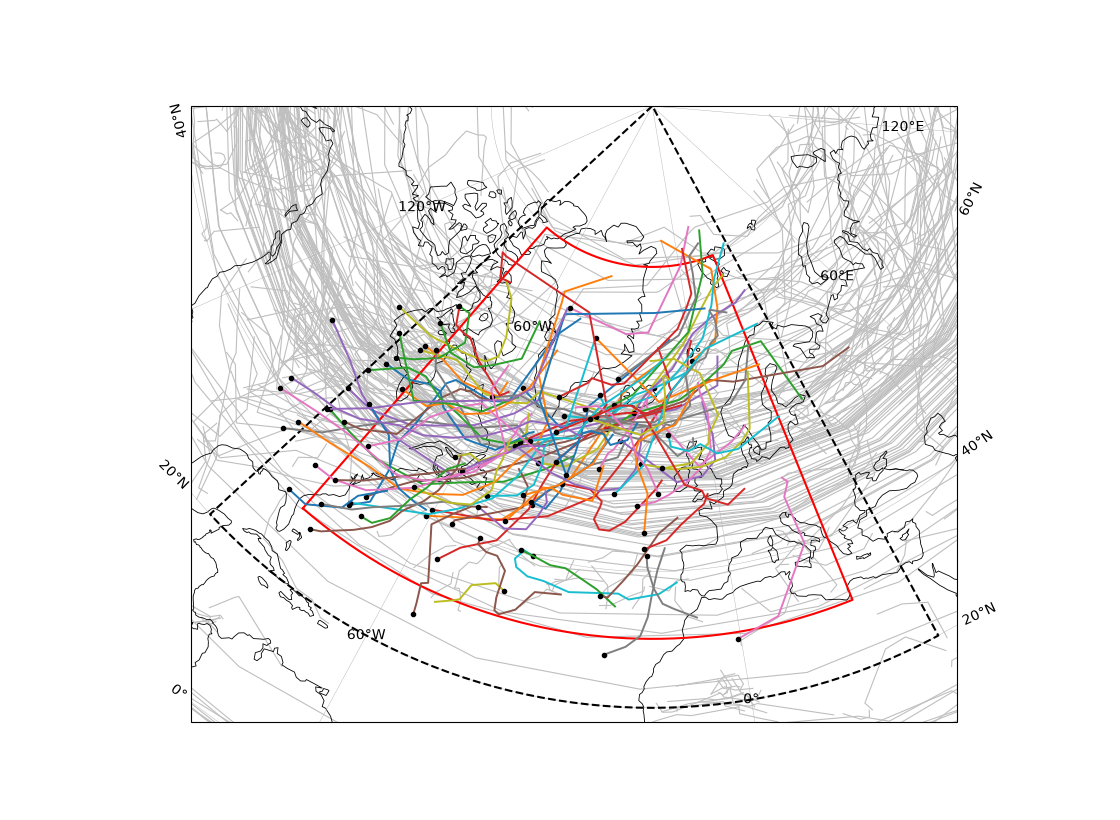

In [7]:
st.plot_regional_tracks(st_tracks, REGION, DOMAIN, summary=summary,
                        title=f'{len(tracks)} of {len(st_tracks)} tracks kept, '
                              f'{len(summary)} of {len(tracks)} tracks after filtering',
                        )